In [ ]:
!pip install shap optuna --quiet

# Sprint 3 – Modelagem Avançada, Tuning e Interpretabilidade

**Projeto:** Previsão de Visitação – Zoológico de Helsinque (Korkeasaaren Eläintarha)  
**Curso:** Fiap Inteligencia Artificial - Machine Learning  

---

## Contexto

Na Sprint 2, foi criada uma modelagem inicial para previsão da visitação do zoológico. Nesta Sprint 3, o objetivo é evoluir a solução aplicando técnicas mais avançadas de Machine Learning, incluindo:

- Feature Engineering;
- Comparação de múltiplos modelos;
- Cross-Validation;
- Tuning de hiperparâmetros com abordagens diferentes;
- Avaliação final em holdout;
- Interpretabilidade com SHAP.

> **Nota sobre os dados:** como a base original da Sprint 2 não está mais disponível, foi construída uma base sintética reproduzível para fins acadêmicos. Essa base simula padrões realistas de visitação de um zoológico ao longo do ano, incluindo sazonalidade, finais de semana e feriados. O objetivo é permitir a aplicação das técnicas de modelagem, tuning e interpretabilidade exigidas na Sprint 3.

## 0. Instalação de dependências

A biblioteca `shap` será usada para interpretar o comportamento do modelo final. O `optuna` será usado como uma segunda abordagem de tuning de hiperparâmetros.

In [ ]:
# ============================================================
# INSTALAÇÃO DE BIBLIOTECAS ADICIONAIS
# ============================================================
# O Google Colab já possui várias bibliotecas instaladas.
# Aqui instalamos apenas as bibliotecas extras necessárias:
# - shap: interpretabilidade do modelo
# - optuna: otimização de hiperparâmetros
# ============================================================

!pip install shap optuna --quiet

## 1. Imports

Nesta etapa importamos as bibliotecas de manipulação de dados, visualização, modelagem, métricas, tuning e interpretabilidade.

In [ ]:
# ============================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================
# pandas e numpy: manipulação e criação dos dados
# matplotlib: gráficos
# scikit-learn: modelos, métricas, validação e tuning
# optuna: tuning bayesiano
# shap: interpretabilidade do modelo
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import date
from IPython.display import display
from scipy.stats import randint, uniform

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

import optuna
import shap

optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams["figure.figsize"] = (10, 5)

print("✅ Imports concluídos com sucesso!")

✅ Imports concluídos com sucesso!


## 2. Criação da base sintética

Como a base original foi perdida, a base abaixo foi reconstruída de forma sintética e reproduzível. Ela simula um ano completo de visitação, considerando padrões esperados em um zoológico:

- maior visitação no verão;
- menor visitação no inverno;
- aumento nos finais de semana;
- pequeno aumento em feriados;
- ruído aleatório para representar variações naturais.

In [ ]:
# ============================================================
# CRIAÇÃO DOS DADOS SINTÉTICOS
# ============================================================
# Objetivo:
# Criar uma base com 365 registros, representando todos os dias
# do ano de 2023.
#
# A variável alvo principal será:
# - visitors: quantidade diária de visitantes
#
# Também serão criadas variáveis explicativas como:
# - mês
# - dia da semana
# - final de semana
# - feriado
# ============================================================

np.random.seed(42)

# Gera uma sequência com todos os dias do ano de 2023
datas = pd.date_range(start="2023-01-01", end="2023-12-31", freq="D")

# Lista simplificada de feriados finlandeses em 2023
holidays_2023 = [
    date(2023, 1, 1), date(2023, 1, 6), date(2023, 4, 7),
    date(2023, 4, 9), date(2023, 4, 10), date(2023, 5, 1),
    date(2023, 5, 18), date(2023, 6, 23), date(2023, 6, 24),
    date(2023, 11, 4), date(2023, 12, 6), date(2023, 12, 24),
    date(2023, 12, 25), date(2023, 12, 26)
]

registros = []

for dt in datas:
    mes = dt.month
    dia = dt.day
    dia_semana_num = dt.dayofweek  # 0 = segunda, 6 = domingo
    is_weekend = 1 if dia_semana_num >= 5 else 0
    is_holiday = 1 if dt.date() in holidays_2023 else 0

    # Padrão sazonal:
    # a visitação aumenta nos meses mais quentes e cai nos meses frios.
    base_sazonal = 1800 + 2200 * np.sin(np.pi * (mes - 1) / 11)

    # Finais de semana costumam aumentar a visitação.
    fator_fds = 1.30 if is_weekend else 1.00

    # Feriados também podem aumentar a visitação.
    fator_feriado = 1.15 if is_holiday else 1.00

    # Ruído aleatório para simular variações naturais de público.
    ruido = np.random.uniform(0.80, 1.20)

    visitors = int(base_sazonal * fator_fds * fator_feriado * ruido)
    visitors = max(visitors, 50)

    registros.append({
        "date": dt,
        "mes": mes,
        "dia": dia,
        "dia_semana_num": dia_semana_num,
        "is_weekend": is_weekend,
        "is_holiday": is_holiday,
        "visitors": visitors
    })

# Criação do DataFrame principal
df = pd.DataFrame(registros)

print(f"✅ Base criada com {len(df)} registros")
print(f"Média diária de visitantes: {df['visitors'].mean():.0f}")
print(f"Mínimo de visitantes: {df['visitors'].min()}")
print(f"Máximo de visitantes: {df['visitors'].max()}")

display(df.head())

✅ Base criada com 365 registros
Média diária de visitantes: 3354
Mínimo de visitantes: 1454
Máximo de visitantes: 6291


,date,mes,dia,dia_semana_num,is_weekend,is_holiday,visitors
0,2023-01-01,1,1,6,1,1,2555
1,2023-01-02,1,2,0,0,0,2124
2,2023-01-03,1,3,1,0,0,1967
3,2023-01-04,1,4,2,0,0,1871
4,2023-01-05,1,5,3,0,0,1552


## 3. Análise exploratória inicial

Antes de treinar os modelos, é importante observar como a visitação se comporta ao longo do ano e entre dias úteis e finais de semana.

Estatísticas da variável visitors:


,visitors
count,365.000000
mean,3353.739726
std,1043.415943
min,1454.000000
25%,2527.000000
50%,3346.000000
75%,4108.000000
max,6291.000000


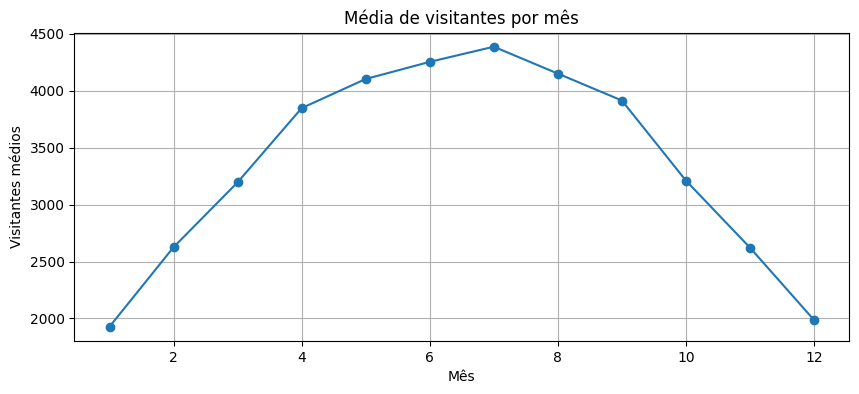

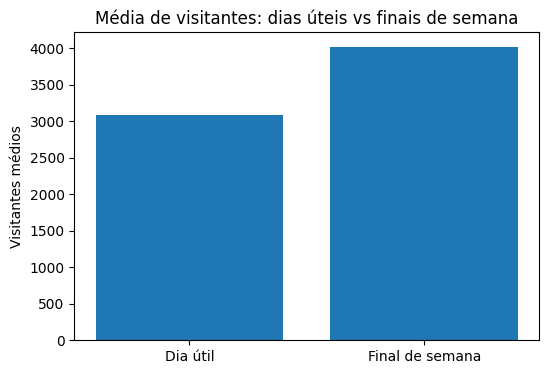

In [ ]:
# ============================================================
# ANÁLISE EXPLORATÓRIA INICIAL
# ============================================================
# Nesta etapa analisamos:
# - estatísticas gerais da variável visitors
# - média de visitantes por mês
# - diferença entre dias úteis e finais de semana
# ============================================================

print("Estatísticas da variável visitors:")
display(df["visitors"].describe())

media_mes = df.groupby("mes")["visitors"].mean()
media_fds = df.groupby("is_weekend")["visitors"].mean()

plt.figure(figsize=(10, 4))
plt.plot(media_mes.index, media_mes.values, marker="o")
plt.title("Média de visitantes por mês")
plt.xlabel("Mês")
plt.ylabel("Visitantes médios")
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(["Dia útil", "Final de semana"], media_fds.values)
plt.title("Média de visitantes: dias úteis vs finais de semana")
plt.ylabel("Visitantes médios")
plt.show()

## 4. Feature Engineering

Nesta etapa criamos novas variáveis para melhorar o desempenho dos modelos. Como a visitação depende fortemente do calendário, foram criadas variáveis temporais e cíclicas.

In [ ]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================
# Criamos novas features para representar melhor os padrões temporais.
#
# Principais ideias:
# - dia_do_ano: posição do dia dentro do ano
# - trimestre: agrupamento dos meses
# - estação do ano: inverno, primavera, verão e outono
# - variáveis cíclicas sin/cos: representam mês e dia da semana
#   de forma circular, evitando que dezembro e janeiro fiquem
#   matematicamente distantes.
# ============================================================

def get_season(mes):
    if mes in [12, 1, 2]:
        return "Winter"
    elif mes in [3, 4, 5]:
        return "Spring"
    elif mes in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

season_map = {
    "Winter": 0,
    "Spring": 1,
    "Summer": 2,
    "Autumn": 3
}

# Criação das features temporais
df["dia_do_ano"] = df["date"].dt.dayofyear
df["trimestre"] = df["date"].dt.quarter
df["season"] = df["mes"].apply(get_season)
df["season_enc"] = df["season"].map(season_map)
df["is_summer"] = df["mes"].isin([6, 7, 8]).astype(int)

# Codificação cíclica do mês
df["mes_sin"] = np.sin(2 * np.pi * df["mes"] / 12)
df["mes_cos"] = np.cos(2 * np.pi * df["mes"] / 12)

# Codificação cíclica do dia da semana
df["dia_semana_sin"] = np.sin(2 * np.pi * df["dia_semana_num"] / 7)
df["dia_semana_cos"] = np.cos(2 * np.pi * df["dia_semana_num"] / 7)

# Criação de uma variável categórica para classificação
# Baixa: 25% menores valores
# Média: valores intermediários
# Alta: 25% maiores valores
q1 = df["visitors"].quantile(0.25)
q3 = df["visitors"].quantile(0.75)

def categorizar_visitacao(valor):
    if valor <= q1:
        return "Baixa"
    elif valor <= q3:
        return "Média"
    else:
        return "Alta"

df["visitacao_class"] = df["visitors"].apply(categorizar_visitacao)

print("✅ Feature Engineering concluído")
display(df.head())

✅ Feature Engineering concluído


,date,mes,dia,dia_semana_num,is_weekend,is_holiday,visitors,dia_do_ano,trimestre,season,season_enc,is_summer,mes_sin,mes_cos,dia_semana_sin,dia_semana_cos,visitacao_class
0,2023-01-01,1,1,6,1,1,2555,1,1,Winter,0,0,0.5,0.866025,-0.781831,0.623490,Média
1,2023-01-02,1,2,0,0,0,2124,2,1,Winter,0,0,0.5,0.866025,0.000000,1.000000,Baixa
2,2023-01-03,1,3,1,0,0,1967,3,1,Winter,0,0,0.5,0.866025,0.781831,0.623490,Baixa
3,2023-01-04,1,4,2,0,0,1871,4,1,Winter,0,0,0.5,0.866025,0.974928,-0.222521,Baixa
4,2023-01-05,1,5,3,0,0,1552,5,1,Winter,0,0,0.5,0.866025,0.433884,-0.900969,Baixa


## 5. Separação entre treino e teste

O conjunto de teste será usado apenas no final, para avaliar a capacidade de generalização dos modelos.

In [ ]:
# ============================================================
# SEPARAÇÃO DAS VARIÁVEIS E HOLDOUT
# ============================================================
# X: variáveis preditoras
# y_reg: variável alvo de regressão, com número de visitantes
# y_clf: variável alvo de classificação, com classes Baixa/Média/Alta
#
# O holdout reserva 20% dos dados para teste final.
# ============================================================

FEATURES = [
    "mes",
    "dia",
    "dia_do_ano",
    "trimestre",
    "dia_semana_num",
    "is_weekend",
    "is_holiday",
    "season_enc",
    "is_summer",
    "mes_sin",
    "mes_cos",
    "dia_semana_sin",
    "dia_semana_cos"
]

X = df[FEATURES]
y_reg = df["visitors"]
y_clf = df["visitacao_class"]

X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Treino regressão: {X_train.shape[0]} registros")
print(f"Teste regressão : {X_test.shape[0]} registros")
print(f"Treino classificação: {X_train_clf.shape[0]} registros")
print(f"Teste classificação : {X_test_clf.shape[0]} registros")

Treino regressão: 292 registros
Teste regressão : 73 registros
Treino classificação: 292 registros
Teste classificação : 73 registros


## 6. Modelagem de regressão com Cross-Validation

Aqui comparamos modelos de regressão antes do tuning. A métrica principal será o R² médio obtido com validação cruzada 5-fold.

,Modelo,R2_medio_CV,Desvio_CV
0,Ridge,0.796554,0.036072
1,Random Forest,0.796281,0.022982
2,Gradient Boosting,0.791603,0.022959


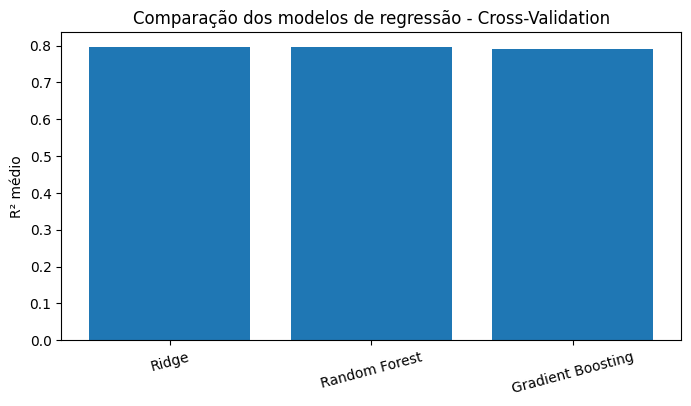

In [ ]:
# ============================================================
# CROSS-VALIDATION PARA MODELOS DE REGRESSÃO
# ============================================================
# Modelos avaliados:
# - Ridge Regression
# - Random Forest Regressor
# - Gradient Boosting Regressor
#
# Métrica usada:
# - R², que mede o quanto o modelo explica a variação dos dados.
# ============================================================

kf = KFold(n_splits=5, shuffle=True, random_state=42)

modelos_reg = {
    "Ridge": Ridge(),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

resultados_cv_reg = []

for nome, modelo in modelos_reg.items():
    scores = cross_val_score(
        modelo,
        X_train,
        y_train_reg,
        cv=kf,
        scoring="r2",
        n_jobs=-1
    )

    resultados_cv_reg.append({
        "Modelo": nome,
        "R2_medio_CV": scores.mean(),
        "Desvio_CV": scores.std()
    })

resultado_reg_df = pd.DataFrame(resultados_cv_reg).sort_values("R2_medio_CV", ascending=False)
display(resultado_reg_df)

plt.figure(figsize=(8, 4))
plt.bar(resultado_reg_df["Modelo"], resultado_reg_df["R2_medio_CV"])
plt.title("Comparação dos modelos de regressão - Cross-Validation")
plt.ylabel("R² médio")
plt.xticks(rotation=15)
plt.show()

## 7. Tuning de hiperparâmetros

O enunciado solicita pelo menos duas abordagens diferentes de tuning. Neste notebook usamos três:

1. GridSearchCV;
2. RandomizedSearchCV;
3. Optuna.

In [ ]:
# ============================================================
# TUNING 1: GRIDSEARCHCV COM RANDOM FOREST
# ============================================================
# O GridSearchCV testa todas as combinações definidas no grid.
# É simples e completo, mas pode ser custoso se o grid for grande.
# ============================================================

param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

inicio = time.time()

grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train_reg)

tempo_grid = time.time() - inicio

print("✅ GridSearchCV concluído")
print("Melhores parâmetros:", grid_rf.best_params_)
print(f"Melhor R² médio em CV: {grid_rf.best_score_:.4f}")
print(f"Tempo de execução: {tempo_grid:.2f} segundos")

✅ GridSearchCV concluído
Melhores parâmetros: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Melhor R² médio em CV: 0.7884
Tempo de execução: 57.96 segundos


In [ ]:
# ============================================================
# TUNING 2: RANDOMIZEDSEARCHCV COM GRADIENT BOOSTING
# ============================================================
# O RandomizedSearchCV não testa todas as combinações.
# Ele sorteia um número definido de combinações dentro do espaço.
# É útil quando há muitos hiperparâmetros possíveis.
# ============================================================

param_dist_gb = {
    "n_estimators": randint(100, 500),
    "max_depth": randint(2, 8),
    "learning_rate": uniform(0.01, 0.20),
    "subsample": uniform(0.70, 0.30),
    "min_samples_split": randint(2, 10)
}

inicio = time.time()

random_gb = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist_gb,
    n_iter=30,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_gb.fit(X_train, y_train_reg)

tempo_random = time.time() - inicio

print("✅ RandomizedSearchCV concluído")
print("Melhores parâmetros:", random_gb.best_params_)
print(f"Melhor R² médio em CV: {random_gb.best_score_:.4f}")
print(f"Tempo de execução: {tempo_random:.2f} segundos")

✅ RandomizedSearchCV concluído
Melhores parâmetros: {'learning_rate': np.float64(0.01628583713734685), 'max_depth': 2, 'min_samples_split': 5, 'n_estimators': 195, 'subsample': np.float64(0.9086548259278382)}
Melhor R² médio em CV: 0.8016
Tempo de execução: 53.17 segundos


In [ ]:
# ============================================================
# TUNING 3: OPTUNA COM GRADIENT BOOSTING
# ============================================================
# O Optuna usa otimização bayesiana.
# Em vez de testar aleatoriamente, ele usa os resultados anteriores
# para sugerir novas combinações de hiperparâmetros.
# ============================================================

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "subsample": trial.suggest_float("subsample", 0.70, 1.00),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5)
    }

    modelo = GradientBoostingRegressor(random_state=42, **params)

    scores = cross_val_score(
        modelo,
        X_train,
        y_train_reg,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    return scores.mean()

inicio = time.time()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

tempo_optuna = time.time() - inicio

print("✅ Optuna concluído")
print("Melhores parâmetros:", study.best_params)
print(f"Melhor R² médio em CV: {study.best_value:.4f}")
print(f"Tempo de execução: {tempo_optuna:.2f} segundos")

✅ Optuna concluído
Melhores parâmetros: {'n_estimators': 371, 'max_depth': 2, 'learning_rate': 0.026448731402139526, 'subsample': 0.945788411464178, 'min_samples_split': 7, 'min_samples_leaf': 4}
Melhor R² médio em CV: 0.8118
Tempo de execução: 55.46 segundos


## 8. Comparação dos tunings

Abaixo comparamos os resultados dos três métodos de tuning, observando tanto o desempenho quanto o tempo de execução.

,Metodo,R2_CV,Tempo_segundos
2,Optuna - Gradient Boosting,0.811825,55.458452
1,RandomizedSearchCV - Gradient Boosting,0.801564,53.165197
0,GridSearchCV - Random Forest,0.788437,57.960997


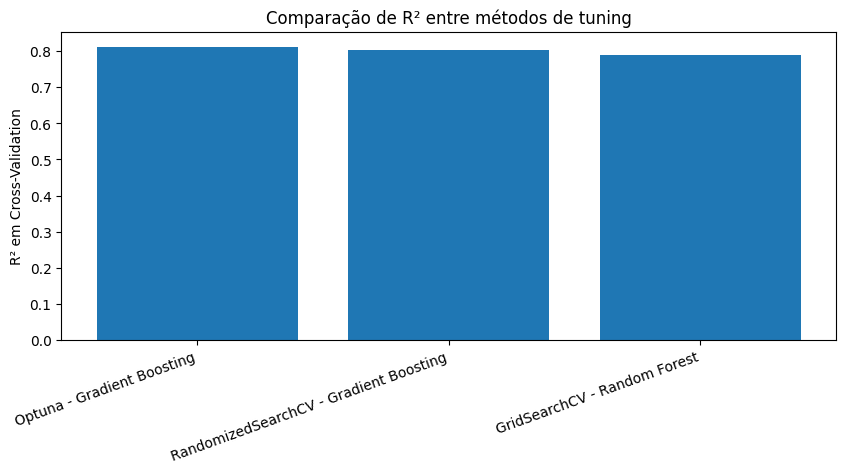

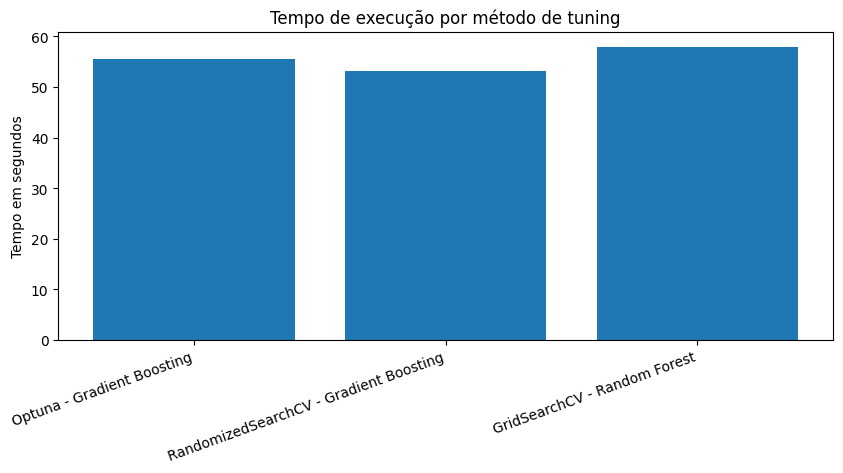

In [ ]:
# ============================================================
# COMPARAÇÃO DOS MÉTODOS DE TUNING
# ============================================================
# Aqui reunimos os resultados em uma tabela e criamos gráficos
# para facilitar a comparação entre as estratégias.
# ============================================================

comparacao_tuning = pd.DataFrame({
    "Metodo": [
        "GridSearchCV - Random Forest",
        "RandomizedSearchCV - Gradient Boosting",
        "Optuna - Gradient Boosting"
    ],
    "R2_CV": [
        grid_rf.best_score_,
        random_gb.best_score_,
        study.best_value
    ],
    "Tempo_segundos": [
        tempo_grid,
        tempo_random,
        tempo_optuna
    ]
})

comparacao_tuning = comparacao_tuning.sort_values("R2_CV", ascending=False)
display(comparacao_tuning)

plt.figure(figsize=(10, 4))
plt.bar(comparacao_tuning["Metodo"], comparacao_tuning["R2_CV"])
plt.title("Comparação de R² entre métodos de tuning")
plt.ylabel("R² em Cross-Validation")
plt.xticks(rotation=20, ha="right")
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(comparacao_tuning["Metodo"], comparacao_tuning["Tempo_segundos"])
plt.title("Tempo de execução por método de tuning")
plt.ylabel("Tempo em segundos")
plt.xticks(rotation=20, ha="right")
plt.show()

## 9. Avaliação final do melhor modelo de regressão

Após o tuning, escolhemos o melhor modelo com base no R² médio em Cross-Validation. Em seguida, avaliamos esse modelo no conjunto holdout, que ainda não foi usado no treinamento.

In [ ]:
# ============================================================
# SELEÇÃO DO MELHOR MODELO DE REGRESSÃO
# ============================================================
# Para simplificar e manter o notebook reprodutível, selecionamos
# automaticamente o melhor modelo entre os três métodos de tuning.
# Depois treinamos esse modelo com todo o conjunto de treino.
# ============================================================

candidatos = {
    "GridSearchCV - Random Forest": grid_rf.best_estimator_,
    "RandomizedSearchCV - Gradient Boosting": random_gb.best_estimator_,
    "Optuna - Gradient Boosting": GradientBoostingRegressor(random_state=42, **study.best_params)
}

melhor_metodo = comparacao_tuning.iloc[0]["Metodo"]
melhor_modelo_reg = candidatos[melhor_metodo]

melhor_modelo_reg.fit(X_train, y_train_reg)

y_pred_reg = melhor_modelo_reg.predict(X_test)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"Melhor método selecionado: {melhor_metodo}")
print("\n=== Métricas finais no holdout ===")
print(f"MAE : {mae:.2f} visitantes")
print(f"RMSE: {rmse:.2f} visitantes")
print(f"R²  : {r2:.4f}")

Melhor método selecionado: Optuna - Gradient Boosting

=== Métricas finais no holdout ===
MAE : 346.60 visitantes
RMSE: 404.34 visitantes
R²  : 0.8581


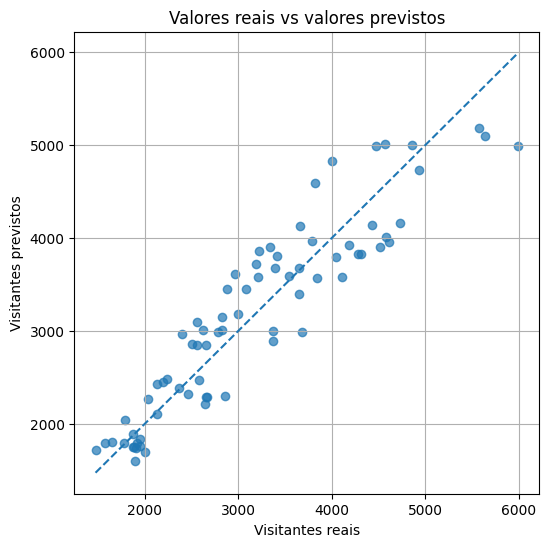

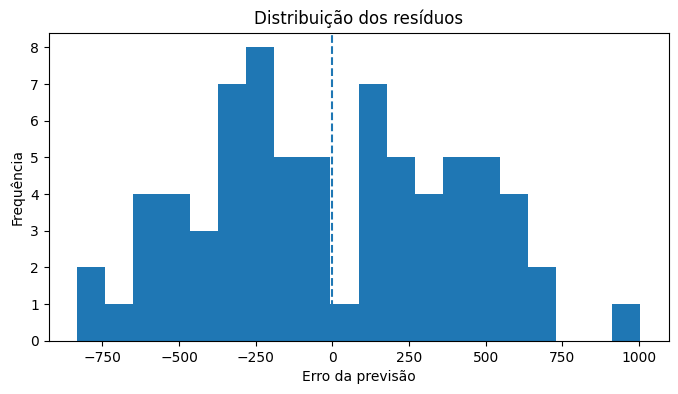

In [ ]:
# ============================================================
# GRÁFICO DE VALORES REAIS VS PREVISTOS
# ============================================================
# Quanto mais próximos os pontos estiverem da linha diagonal,
# melhor é a previsão do modelo.
# ============================================================

plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.7)

limites = [
    min(y_test_reg.min(), y_pred_reg.min()),
    max(y_test_reg.max(), y_pred_reg.max())
]

plt.plot(limites, limites, linestyle="--")
plt.title("Valores reais vs valores previstos")
plt.xlabel("Visitantes reais")
plt.ylabel("Visitantes previstos")
plt.grid(True)
plt.show()

# Resíduos
residuos = y_test_reg - y_pred_reg

plt.figure(figsize=(8, 4))
plt.hist(residuos, bins=20)
plt.axvline(0, linestyle="--")
plt.title("Distribuição dos resíduos")
plt.xlabel("Erro da previsão")
plt.ylabel("Frequência")
plt.show()

## 10. Modelagem de classificação

Além da regressão, também treinamos modelos de classificação para prever se a visitação será Baixa, Média ou Alta.

In [ ]:
# ============================================================
# MODELOS DE CLASSIFICAÇÃO
# ============================================================
# Modelos avaliados:
# - KNN
# - Random Forest Classifier
# - Gradient Boosting Classifier
#
# Métrica principal:
# - Accuracy em validação cruzada
# ============================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos_clf = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

resultados_cv_clf = []

for nome, modelo in modelos_clf.items():
    scores = cross_val_score(
        modelo,
        X_train_clf,
        y_train_clf,
        cv=skf,
        scoring="accuracy",
        n_jobs=-1
    )

    resultados_cv_clf.append({
        "Modelo": nome,
        "Accuracy_CV": scores.mean(),
        "Desvio_CV": scores.std()
    })

resultado_clf_df = pd.DataFrame(resultados_cv_clf).sort_values("Accuracy_CV", ascending=False)
display(resultado_clf_df)

,Modelo,Accuracy_CV,Desvio_CV
1,Random Forest,0.787610,0.035759
2,Gradient Boosting,0.756634,0.070729
0,KNN,0.640327,0.020141


=== Avaliação final da classificação ===
Accuracy : 0.8630
Precision: 0.8681
Recall   : 0.8630

Melhores parâmetros: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 158}

Relatório de classificação:
              precision    recall  f1-score   support

        Alta       0.93      0.78      0.85        18
       Baixa       0.81      0.94      0.87        18
       Média       0.86      0.86      0.86        37

    accuracy                           0.86        73
   macro avg       0.87      0.86      0.86        73
weighted avg       0.87      0.86      0.86        73



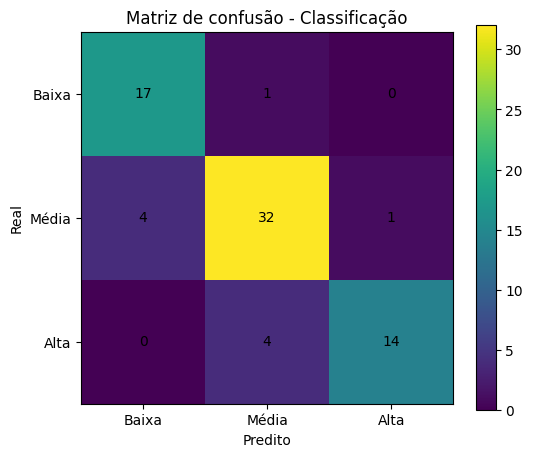

In [ ]:
# ============================================================
# TUNING DO MODELO DE CLASSIFICAÇÃO
# ============================================================
# Aplicamos RandomizedSearchCV no Random Forest Classifier.
# Depois avaliamos o modelo no conjunto de teste final.
# ============================================================

param_dist_rfc = {
    "n_estimators": randint(100, 400),
    "max_depth": [None, 10, 15, 20],
    "min_samples_split": randint(2, 8),
    "min_samples_leaf": randint(1, 4)
}

random_rfc = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rfc,
    n_iter=20,
    cv=skf,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_rfc.fit(X_train_clf, y_train_clf)

melhor_modelo_clf = random_rfc.best_estimator_
y_pred_clf = melhor_modelo_clf.predict(X_test_clf)

accuracy = accuracy_score(y_test_clf, y_pred_clf)
precision = precision_score(y_test_clf, y_pred_clf, average="weighted")
recall = recall_score(y_test_clf, y_pred_clf, average="weighted")

print("=== Avaliação final da classificação ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print("\nMelhores parâmetros:", random_rfc.best_params_)
print("\nRelatório de classificação:")
print(classification_report(y_test_clf, y_pred_clf))

labels = ["Baixa", "Média", "Alta"]
cm = confusion_matrix(y_test_clf, y_pred_clf, labels=labels)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Matriz de confusão - Classificação")
plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)
plt.xlabel("Predito")
plt.ylabel("Real")

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

## 11. Interpretabilidade com SHAP

O SHAP ajuda a explicar quais variáveis mais influenciam as previsões do modelo final de regressão.

In [ ]:
# ============================================================
# INTERPRETABILIDADE COM SHAP
# ============================================================
# O SHAP calcula a contribuição de cada feature para as previsões.
# Isso ajuda a entender se o modelo está aprendendo padrões coerentes,
# como sazonalidade, fim de semana e posição no ano.
# ============================================================

explainer = shap.Explainer(melhor_modelo_reg, X_train)
shap_values = explainer(X_test)

print("✅ Valores SHAP calculados")

✅ Valores SHAP calculados


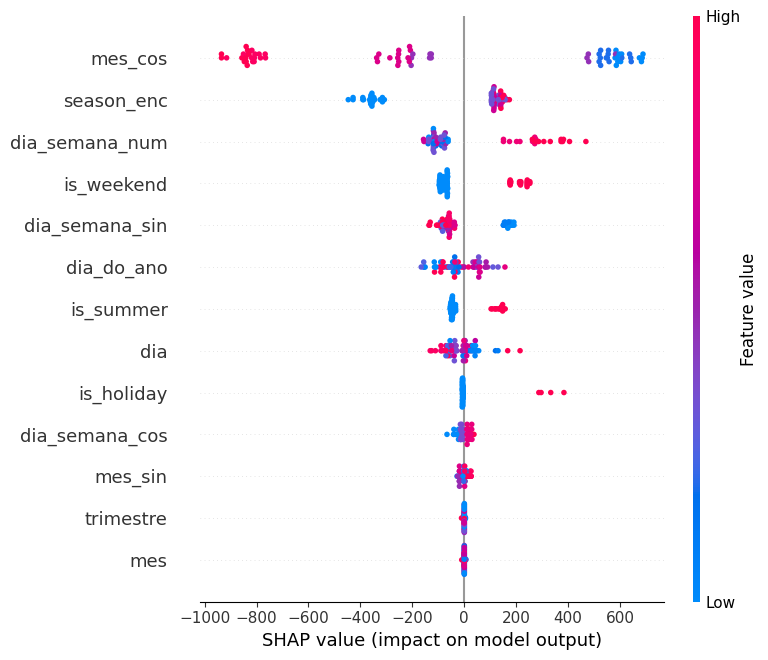

In [ ]:
# ============================================================
# SHAP SUMMARY PLOT
# ============================================================
# Este gráfico mostra:
# - quais variáveis são mais importantes;
# - se elas aumentam ou reduzem a previsão;
# - como cada observação foi impactada.
# ============================================================

shap.summary_plot(shap_values, X_test, show=True)

,Feature,Importancia_SHAP
10,mes_cos,562.834938
7,season_enc,211.845422
4,dia_semana_num,153.200097
5,is_weekend,117.977157
11,dia_semana_sin,98.356173
2,dia_do_ano,65.892300
8,is_summer,63.587361
1,dia,45.227107
6,is_holiday,23.605113
12,dia_semana_cos,18.197587


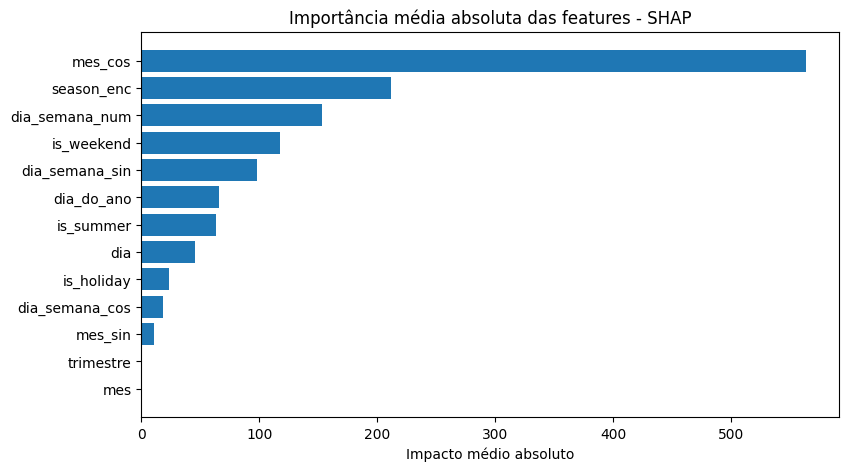

In [ ]:
# ============================================================
# IMPORTÂNCIA MÉDIA ABSOLUTA DAS FEATURES
# ============================================================
# Calculamos a média absoluta dos valores SHAP para identificar
# quais variáveis tiveram maior impacto global no modelo.
# ============================================================

shap_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importancia_SHAP": np.abs(shap_values.values).mean(axis=0)
}).sort_values("Importancia_SHAP", ascending=False)

display(shap_importance)

plt.figure(figsize=(9, 5))
plt.barh(shap_importance["Feature"], shap_importance["Importancia_SHAP"])
plt.title("Importância média absoluta das features - SHAP")
plt.xlabel("Impacto médio absoluto")
plt.gca().invert_yaxis()
plt.show()

Previsão individual de alta visitação: 5188 visitantes


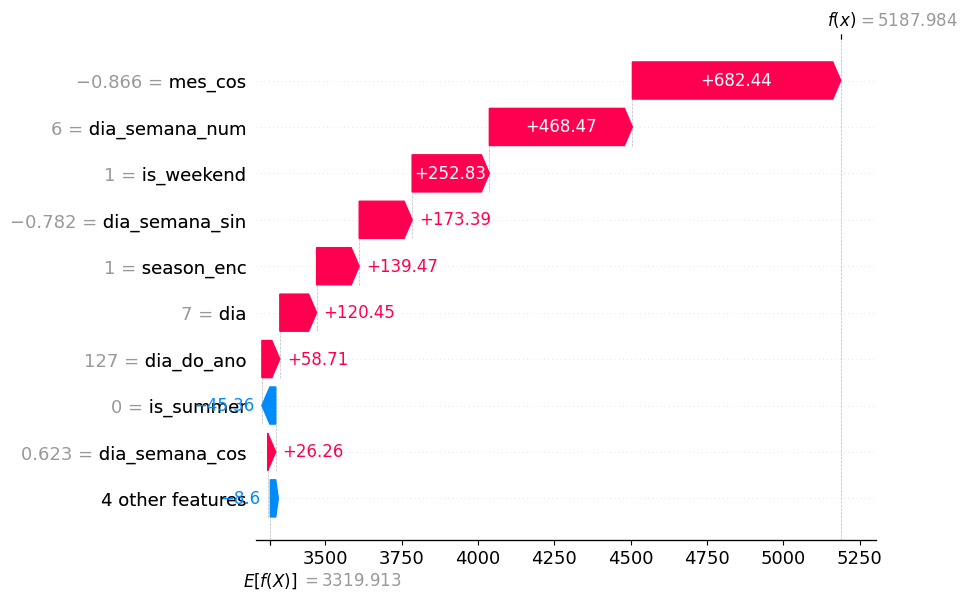

Previsão individual de baixa visitação: 1599 visitantes


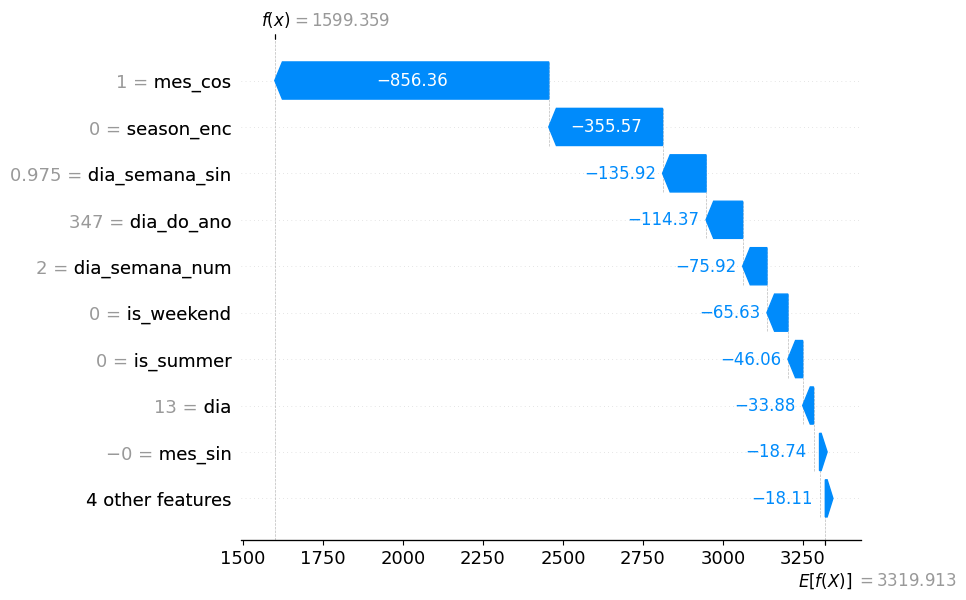

In [ ]:
# ============================================================
# EXPLICAÇÃO DE PREVISÕES INDIVIDUAIS
# ============================================================
# O waterfall plot mostra como cada variável empurrou uma previsão
# específica para cima ou para baixo em relação ao valor base.
# ============================================================

idx_alta = int(np.argmax(y_pred_reg))
idx_baixa = int(np.argmin(y_pred_reg))

print(f"Previsão individual de alta visitação: {y_pred_reg[idx_alta]:.0f} visitantes")
shap.plots.waterfall(shap_values[idx_alta])

print(f"Previsão individual de baixa visitação: {y_pred_reg[idx_baixa]:.0f} visitantes")
shap.plots.waterfall(shap_values[idx_baixa])

## 12. Resumo final das métricas

Nesta etapa consolidamos as principais métricas obtidas nos modelos de regressão e classificação.

In [ ]:
# ============================================================
# RESUMO FINAL DAS MÉTRICAS
# ============================================================
# Esta tabela resume os principais resultados finais do trabalho.
# ============================================================

resumo_final = pd.DataFrame({
    "Tipo": ["Regressão", "Classificação"],
    "Modelo final": [melhor_metodo, "Random Forest Classifier Tuned"],
    "Métrica principal": ["R²", "Accuracy"],
    "Resultado": [r2, accuracy],
    "Métrica adicional 1": [f"MAE = {mae:.2f}", f"Precision = {precision:.4f}"],
    "Métrica adicional 2": [f"RMSE = {rmse:.2f}", f"Recall = {recall:.4f}"]
})

display(resumo_final)

,Tipo,Modelo final,Métrica principal,Resultado,Métrica adicional 1,Métrica adicional 2
0,Regressão,Optuna - Gradient Boosting,R²,0.858147,MAE = 346.60,RMSE = 404.34
1,Classificação,Random Forest Classifier Tuned,Accuracy,0.863014,Precision = 0.8681,Recall = 0.8630


## 13. Conclusão

A Sprint 3 evoluiu a modelagem inicial por meio da aplicação de técnicas mais avançadas de Machine Learning. A criação de novas variáveis temporais permitiu que os modelos capturassem melhor o comportamento sazonal da visitação do zoológico.

Foram avaliados múltiplos modelos de regressão e classificação, utilizando Cross-Validation para obter uma estimativa mais robusta de desempenho. Também foram aplicadas três estratégias de tuning: GridSearchCV, RandomizedSearchCV e Optuna. Isso permitiu comparar diferentes formas de busca por hiperparâmetros.

Na etapa final, o melhor modelo de regressão foi avaliado em holdout usando MAE, RMSE e R². Para classificação, foram avaliadas as métricas Accuracy, Precision e Recall. Além disso, o SHAP foi utilizado para interpretar o modelo, mostrando quais variáveis mais influenciaram as previsões.

Apesar da base utilizada ser sintética, ela foi construída de forma transparente e reproduzível para simular padrões realistas de visitação. Portanto, o notebook atende ao objetivo acadêmico da Sprint 3: demonstrar a aplicação de modelagem avançada, tuning, validação robusta e interpretabilidade.